<a href="https://colab.research.google.com/github/Krish-sharma-2003/ML-s-Google-Colab-Practice-Notes/blob/main/RMSprop%20VS%20Gradient%20Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
import numpy as np
import matplotlib.pyplot as plt


In [89]:
def quadratic_loss(x, y):
  return x**2 + 10 * y**2


In [90]:
def quadratic_grad(x, y):
  dx = 2 * x
  dy = 20 * y
  return np.array([dx, dy])


In [91]:
def batch_gradient_descent(grad_func, eta, epochs, start_point):
  x,y = start_point
  path = [(x, y)]
  losses = [quadratic_loss(x, y)]

  for _ in range(epochs):
      grad = grad_func(x, y)
      x -= eta * grad[0]
      y -= eta * grad[1]
      path.append((x, y))
      losses.append(quadratic_loss(x, y))

  return np.array(path), losses

In [92]:
def rmsprop_optimizer(grad_func, eta, beta, epsilon, epochs, start_point):
  x,y = start_point
  Eg2 = np.array([0.0, 0.0])  #Moving average of squared gradients
  path = [(x, y)]
  losses = [quadratic_loss(x, y)]

  for _ in range(epochs):
      grad = grad_func(x, y)
      Eg2 = beta * Eg2 + (1 - beta) * (grad ** 2)

      x -= eta * grad[0] / (np.sqrt(Eg2[0]) + epsilon) #Update x
      y -= eta * grad[1] / (np.sqrt(Eg2[1]) + epsilon) #update y

      path.append((x, y))
      losses.append(quadratic_loss(x, y))


  return np.array(path), losses

In [93]:
def plot_paths(function, paths, labels, title):
    x, y = np.meshgrid(np.linspace(-2, 2, 400), np.linspace(-2, 2, 400))
    z = function(x, y)

    plt.figure(figsize=(8, 6))
    plt.contour(x, y, z, levels=50, cmap='jet')

    for path, label in zip(paths, labels):
        plt.plot(path[:, 0], path[:, 1], label=label)
        plt.scatter(path[0, 0], path[0, 1], color='green', label="start")
        plt.scatter(path[-1, 0], path[-1, 1], color='red', label="end")

    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()


In [94]:
def plot_losses(losses, labels, title):
  plt.figure(figsize=(8, 6))

  for loss, label in zip(losses, labels):

      plt.plot(loss, label=label)

  plt.title(title)
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

In [95]:
lr_gd = 0.01
lr_rmsprop = 0.01
beta = 0.9
epsilon = 1e-8
epochs = 20    0
start_point = (1.5, 1.5)

In [96]:
path_gd, losses_gd = batch_gradient_descent(quadratic_grad, lr_gd, epochs, start_point)
path_rmsprop, losses_rmsprop = rmsprop_optimizer(quadratic_grad, lr_rmsprop, beta, epsilon, epochs, start_point)

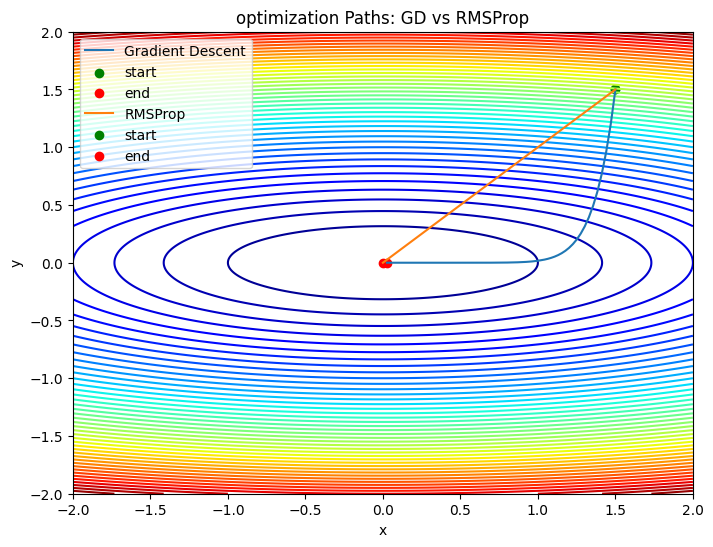

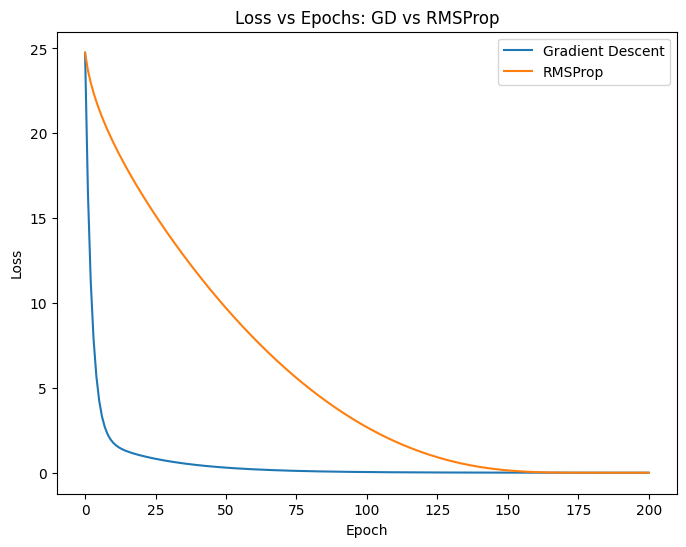

In [97]:
plot_paths(quadratic_loss, [path_gd, path_rmsprop],
           ["Gradient Descent", "RMSProp"],
           "optimization Paths: GD vs RMSProp")

plot_losses([losses_gd, losses_rmsprop],
            ["Gradient Descent", "RMSProp"],
            "Loss vs Epochs: GD vs RMSProp")